In [1]:
!pip install gym torch numpy matplotlib scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.8 MB/s eta 0:00:00


In [2]:
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNetwork(nn.Module):
    """
    A neural network for policy-based reinforcement learning.

    This network takes an input state and outputs a probability distribution over actions.
    """

    def __init__(self, input_dim: int, output_dim: int) -> None:
        """
        Initializes the Policy Network.

        Args:
            input_dim (int): The dimensionality of the input state.
            output_dim (int): The number of possible actions (output size).
        """
        super(PolicyNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),  # Increase layer size
            nn.ReLU(),
            nn.Linear(256, 128),  # Add an extra hidden layer
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Performs a forward pass of the network.

        Args:
            state (torch.Tensor): The input state tensor.

        Returns:
            torch.Tensor: Probability distribution over actions.
        """
        return self.fc(state)

In [4]:
def compute_kl_divergence(policy: PolicyNetwork, old_policy: PolicyNetwork, states: torch.Tensor) -> torch.Tensor:
    """
    Computes the KL divergence between the current policy and an old policy.

    Args:
        policy (PolicyNetwork): The current policy network.
        old_policy (PolicyNetwork): The previous policy network.
        states (torch.Tensor): A batch of states.

    Returns:
        torch.Tensor: The computed and clipped KL divergence.
    """
    old_probs = old_policy(states).detach()
    new_probs = policy(states)

    kl = (old_probs * (old_probs.log() - new_probs.log())).sum(dim=-1).mean()

    # Clip large KL updates to prevent instability
    return torch.clamp(kl, 0, 0.05)  # Constrain KL divergence

In [5]:
def conjugate_gradient(Ax_fn: callable, b: torch.Tensor, n_iters: int = 10, residual_tol: float = 1e-10) -> torch.Tensor:
    """
    Solves the linear system Ax = b using the conjugate gradient method.

    Args:
        Ax_fn (callable): A function that computes Ax for a given x.
        b (torch.Tensor): The right-hand side vector.
        n_iters (int, optional): Maximum number of iterations. Default is 10.
        residual_tol (float, optional): Tolerance for residual stopping condition. Default is 1e-10.

    Returns:
        torch.Tensor: The approximate solution x.
    """
    x = torch.zeros_like(b)
    r = b.clone()
    p = r.clone()
    r_dot_old = torch.dot(r, r)

    for _ in range(n_iters):
        Ap = Ax_fn(p)
        alpha = r_dot_old / torch.dot(p, Ap)
        x += alpha * p
        r -= alpha * Ap
        r_dot_new = torch.dot(r, r)

        if r_dot_new < residual_tol:
            break

        beta = r_dot_new / r_dot_old
        p = r + beta * p
        r_dot_old = r_dot_new

    return x


In [6]:
def trpo_step(policy: PolicyNetwork, old_policy: PolicyNetwork, states: torch.Tensor, actions: torch.Tensor, advantages: torch.Tensor, damping: float = 0.1, max_kl: float = 0.001) -> None:
    """
    Performs a single Trust Region Policy Optimization (TRPO) step.

    Args:
        policy (PolicyNetwork): The current policy network.
        old_policy (PolicyNetwork): The previous policy network.
        states (torch.Tensor): A batch of states.
        actions (torch.Tensor): A batch of actions taken.
        advantages (torch.Tensor): The advantage values corresponding to actions.
        damping (float, optional): Damping coefficient for stability. Default is 0.1.
        max_kl (float, optional): Maximum KL divergence for trust region constraint. Default is 0.001.
    """
    def fisher_vector_product(v: torch.Tensor) -> torch.Tensor:
        kl = compute_kl_divergence(policy, old_policy, states)
        grads = torch.autograd.grad(kl, policy.parameters(), create_graph=True)
        flat_grads = torch.cat([g.view(-1) for g in grads])
        return flat_grads + damping * v

    # Compute policy gradient
    log_probs = policy(states).gather(1, actions.unsqueeze(1)).squeeze()
    old_log_probs = old_policy(states).gather(1, actions.unsqueeze(1)).squeeze().detach()
    loss = (torch.exp(log_probs - old_log_probs) * advantages).mean()

    grads = torch.autograd.grad(loss, policy.parameters())
    policy_gradient = torch.cat([g.view(-1) for g in grads])

    # Solve for step direction using Conjugate Gradient
    step_direction = conjugate_gradient(fisher_vector_product, policy_gradient)

    # Reduce step size further
    step_size = torch.sqrt(2 * max_kl / torch.dot(step_direction, fisher_vector_product(step_direction)))

    # Apply policy update
    with torch.no_grad():
        for param, step in zip(policy.parameters(), step_direction):
            param += step * step_size * 0.05  # Smaller updates


In [7]:

def compute_discounted_rewards(rewards: list[float], gamma: float = 0.99) -> torch.Tensor:
    """
    Computes discounted rewards for an episode.

    Args:
        rewards (list[float]): A list of rewards received at each timestep.
        gamma (float, optional): Discount factor. Default is 0.99.

    Returns:
        torch.Tensor: A tensor of discounted rewards.
    """
    discounted_rewards = []
    total_reward = 0.0
    for r in reversed(rewards):
        total_reward = r + gamma * total_reward
        discounted_rewards.insert(0, total_reward)
    return torch.tensor(discounted_rewards, dtype=torch.float32)

In [8]:
def train_trpo(env: gym.Env, policy: PolicyNetwork, num_episodes: int = 500, gamma: float = 0.99) -> list[float]:
    """
    Trains a policy using Trust Region Policy Optimization (TRPO).

    Args:
        env (gym.Env): The environment to train in.
        policy (PolicyNetwork): The policy network.
        num_episodes (int, optional): Number of episodes for training. Default is 500.
        gamma (float, optional): Discount factor for rewards. Default is 0.99.

    Returns:
        list[float]: A list of total rewards per episode.
    """
    reward_history = []

    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]  # Handle Gym versions that return (state, info)

        log_probs = []
        states = []
        actions = []
        rewards = []

        done = False
        while not done:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            probs = policy(state_tensor)
            action_dist = torch.distributions.Categorical(probs)
            action = action_dist.sample()

            step_result = env.step(action.item())

            if len(step_result) == 5:
                next_state, reward, terminated, truncated, _ = step_result
                done = terminated or truncated  # New Gym API
            else:
                next_state, reward, done, _ = step_result  # Old Gym API

            log_probs.append(action_dist.log_prob(action))
            states.append(state_tensor)
            actions.append(action)
            rewards.append(reward)

            state = next_state

        # Compute discounted rewards and advantages
        discounted_rewards = compute_discounted_rewards(rewards, gamma)
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

        # Convert lists to tensors
        states = torch.cat(states)
        actions = torch.tensor(actions)
        advantages = discounted_rewards

        # Copy old policy before updating
        old_policy = PolicyNetwork(env.observation_space.shape[0], env.action_space.n)
        old_policy.load_state_dict(policy.state_dict())

        # Apply TRPO update
        trpo_step(policy, old_policy, states, actions, advantages)

        total_episode_reward = sum(rewards)
        reward_history.append(total_episode_reward)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}, Total Reward: {total_episode_reward}")

    return reward_history


In [9]:
env = gym.make("CartPole-v1")
policy = PolicyNetwork(env.observation_space.shape[0], env.action_space.n)

reward_history = train_trpo(env, policy, num_episodes=500)

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 50, Total Reward: 31.0
Episode 100, Total Reward: 15.0
Episode 150, Total Reward: 45.0
Episode 200, Total Reward: 10.0
Episode 250, Total Reward: 28.0
Episode 300, Total Reward: 20.0
Episode 350, Total Reward: 27.0
Episode 400, Total Reward: 35.0
Episode 450, Total Reward: 12.0
Episode 500, Total Reward: 15.0


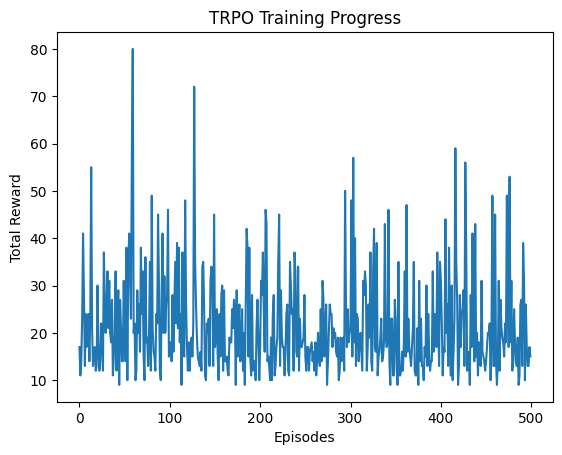

In [10]:
plt.plot(reward_history)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("TRPO Training Progress")
plt.show()